# Calculating TTR

Focusuing on the differences between the Psalms from the Bible and the Psalter. 

In [46]:
import string

def calculate_ttr(text):
    # Remove punctuation and lowercase the text
    clean_text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    
    # Split into a list of words (tokens)
    tokens = clean_text.split()
    
    if not tokens:
        return 0.0
    
    # Extract unique words (types)
    types = set(tokens)
    
    # Calculate ratio
    ttr = len(types) / len(tokens)
    return ttr

# Example Usage
sample_text = "The red dog jumped over the red fox."
print(f"TTR: {calculate_ttr(sample_text):.4f}") 
# Output: 0.7500 (6 unique words / 8 total words)


TTR: 0.7500


## Preparing the Psalms 

In [47]:
import pandas as pd

psalms = pd.read_csv("data/grouped_psalm.csv")

print(psalms.shape)

psalms.head()

(301, 6)


,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...


In [48]:
psalms['TTR'] = psalms['verse'].apply(calculate_ttr)

# psalms.head()

In [49]:
pd.pivot_table(data=psalms, index=['text'], values='TTR', aggfunc='mean')

,TTR
text,
Bible,0.501613
Psalter,0.495528


*From the Article: [Lost in Translationese? Reducing Translation Effect Using Abstract Meaning Representation](https://aclanthology.org/2024.eacl-long.45.pdf)*

> @inproceedings{wein2024lost,
  title={Lost in translationese? reducing translation effect using Abstract Meaning Representation},
  author={Wein, Shira and Schneider, Nathan},
  booktitle={Proceedings of the 18th Conference of the European Chapter of the Association for Computational Linguistics (Volume 1: Long Papers)},
  pages={753--765},
  year={2024}
}


    "type- token ratio decreases from 0.0890 to 0.0850, indicating further diminished linguistic complexity."
    
* From this, we can conclude an overall decrease in lexical complexity in the Psalter compared to the Bible

### Note
if these TTR values were computed on the entire corpus, TTR is sensitive to text length. Since the Bible and Psalter are approximately the same size, the comparison is reasonable, but for publication-quality analysis you might also report a length-normalized metric such as MSTTR, MATTR, or HD-D.


From **Does simplification hold true for machine translations? A corpus-based analysis of lexical diversity in text varieties across genres**

> "Specifically,
with the text length becoming longer, the number of tokens must
increase while types might be repetitive. As a result, some other
indicators based on TTR but uncorrelated with text length have
been created. The present study uses two such indicators, namely
vocd and MTLD (Measure of Textual Lexical Diversity)
(McCarthy and Jarvis, 2010), to measure lexical diversity and
overcome the impact of text length. The two indicators, using
different approaches and capturing unique aspects of lexical
information, have been proven to be the more robust approach to
lexical diversity assessment (McCarthy and Jarvis, 2010)."

%pip install lexical-diversity

In [50]:
def calculate_msttr(text, window_size=50):
    # Basic tokenization (lowercase and split by spaces)
    tokens = [word.strip(".,!?;:()\"'") for word in text.lower().split()]
    
    if len(tokens) < window_size:
        return len(set(tokens)) / len(tokens) if tokens else 0.0
        
    ttr_scores = []
    # Loop through text in fixed chunk segments
    for i in range(0, len(tokens), window_size):
        chunk = tokens[i:i + window_size]
        # Ignore the final chunk if it is shorter than the window size
        if len(chunk) == window_size:
            ttr = len(set(chunk)) / window_size
            ttr_scores.append(ttr)
            
    return sum(ttr_scores) / len(ttr_scores) if ttr_scores else 0.0

In [51]:
psalms['MSTTR'] = psalms['verse'].apply(calculate_msttr)
psalms["psalm_num"] = psalms["psalm_num"].astype(int)
psalms.head()

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,TTR,MSTTR
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,0.473684,0.670000
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,0.582915,0.753333
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,0.573333,0.766667
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,0.593939,0.813333
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,0.483871,0.700000


In [52]:
df = pd.pivot_table(data=psalms, index=['text'], values=['TTR', 'MSTTR'], aggfunc='mean')
df

,MSTTR,TTR
text,,
Bible,0.713610,0.501613
Psalter,0.710904,0.495528


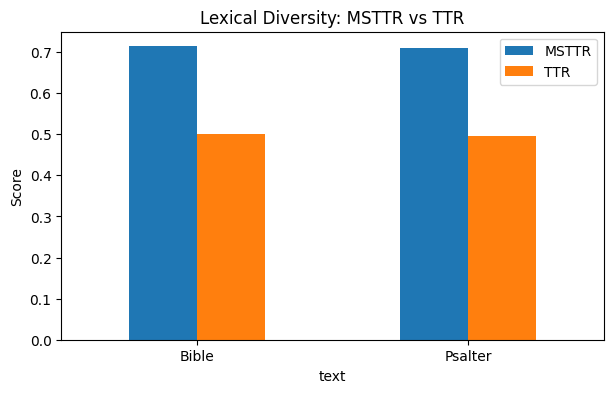

In [53]:
import matplotlib.pyplot as plt

df[['MSTTR', 'TTR']].plot(kind='bar', figsize=(7, 4))
plt.title("Lexical Diversity: MSTTR vs TTR")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Looking closer at groups of psalms known as Kathisma

Kathismas are the 20 divisions of the Book of Psalms used in the Orthodox Christian tradition for liturgical reading. Each Kathisma is divided into three sections called stases, which organize the Psalms into smaller groups for prayer and study. Together, the 20 Kathismas provide a structured way to read through the entire Psalter, with each section **grouping related Psalms for worship and reflection**.

In [54]:
import pandas as pd

psalter_sections = [
    {"Kathisma": "I", "Stasis": "(i)", "Psalms": "1,2,3"},
    {"Kathisma": "I", "Stasis": "(ii)", "Psalms": "4,5,6"},
    {"Kathisma": "I", "Stasis": "(iii)", "Psalms": "7,8"},
    
    {"Kathisma": "II", "Stasis": "(i)", "Psalms": "9,10"},
    {"Kathisma": "II", "Stasis": "(ii)", "Psalms": "11,12,13"},
    {"Kathisma": "II", "Stasis": "(iii)", "Psalms": "14,15,16"},
    
    {"Kathisma": "III", "Stasis": "(i)", "Psalms": "17"},
    {"Kathisma": "III", "Stasis": "(ii)", "Psalms": "18,19,20"},
    {"Kathisma": "III", "Stasis": "(iii)", "Psalms": "21,22,23"},
    
    {"Kathisma": "IV", "Stasis": "(i)", "Psalms": "24,25,26"},
    {"Kathisma": "IV", "Stasis": "(ii)", "Psalms": "27,28,29"},
    {"Kathisma": "IV", "Stasis": "(iii)", "Psalms": "30,31"},
    
    {"Kathisma": "V", "Stasis": "(i)", "Psalms": "32,33"},
    {"Kathisma": "V", "Stasis": "(ii)", "Psalms": "34,35"},
    {"Kathisma": "V", "Stasis": "(iii)", "Psalms": "36"},
    
    {"Kathisma": "VI", "Stasis": "(i)", "Psalms": "37,38,39"},
    {"Kathisma": "VI", "Stasis": "(ii)", "Psalms": "40,41,42"},
    {"Kathisma": "VI", "Stasis": "(iii)", "Psalms": "43,44,45"},
    
    {"Kathisma": "VII", "Stasis": "(i)", "Psalms": "46,47,48"},
    {"Kathisma": "VII", "Stasis": "(ii)", "Psalms": "49,50"},
    {"Kathisma": "VII", "Stasis": "(iii)", "Psalms": "51,52,53,54"},
    
    {"Kathisma": "VIII", "Stasis": "(i)", "Psalms": "55,56,57"},
    {"Kathisma": "VIII", "Stasis": "(ii)", "Psalms": "58,59,60"},
    {"Kathisma": "VIII", "Stasis": "(iii)", "Psalms": "61,62,63"},
    
    {"Kathisma": "IX", "Stasis": "(i)", "Psalms": "64,65,66"},
    {"Kathisma": "IX", "Stasis": "(ii)", "Psalms": "67"},
    {"Kathisma": "IX", "Stasis": "(iii)", "Psalms": "68,69"},
    
    {"Kathisma": "X", "Stasis": "(i)", "Psalms": "70,71"},
    {"Kathisma": "X", "Stasis": "(ii)", "Psalms": "72,73"},
    {"Kathisma": "X", "Stasis": "(iii)", "Psalms": "74,75,76"},
    
    {"Kathisma": "XI", "Stasis": "(i)", "Psalms": "77"},
    {"Kathisma": "XI", "Stasis": "(ii)", "Psalms": "78,79,80"},
    {"Kathisma": "XI", "Stasis": "(iii)", "Psalms": "81,82,83,84"},
    
    {"Kathisma": "XII", "Stasis": "(i)", "Psalms": "85,86,87"},
    {"Kathisma": "XII", "Stasis": "(ii)", "Psalms": "88"},
    {"Kathisma": "XII", "Stasis": "(iii)", "Psalms": "89,90"},
    
    {"Kathisma": "XIII", "Stasis": "(i)", "Psalms": "91,92,93"},
    {"Kathisma": "XIII", "Stasis": "(ii)", "Psalms": "94,95,96"},
    {"Kathisma": "XIII", "Stasis": "(iii)", "Psalms": "97,98,99,100"},
    
    {"Kathisma": "XIV", "Stasis": "(i)", "Psalms": "101,102"},
    {"Kathisma": "XIV", "Stasis": "(ii)", "Psalms": "103"},
    {"Kathisma": "XIV", "Stasis": "(iii)", "Psalms": "104"},
    
    {"Kathisma": "XV", "Stasis": "(i)", "Psalms": "105"},
    {"Kathisma": "XV", "Stasis": "(ii)", "Psalms": "106"},
    {"Kathisma": "XV", "Stasis": "(iii)", "Psalms": "107,108"},
    
    {"Kathisma": "XVI", "Stasis": "(i)", "Psalms": "109,110,111"},
    {"Kathisma": "XVI", "Stasis": "(ii)", "Psalms": "112,113,114"},
    {"Kathisma": "XVI", "Stasis": "(iii)", "Psalms": "115,116,117"},
    
    {"Kathisma": "XVII", "Stasis": "(i)", "Psalms": "118:1-72"},
    {"Kathisma": "XVII", "Stasis": "(ii)", "Psalms": "118:73-131"},
    {"Kathisma": "XVII", "Stasis": "(iii)", "Psalms": "118:132-176"},
    
    {"Kathisma": "XVIII", "Stasis": "(i)", "Psalms": "119,120,121,122,123"},
    {"Kathisma": "XVIII", "Stasis": "(ii)", "Psalms": "124,125,126,127,128"},
    {"Kathisma": "XVIII", "Stasis": "(iii)", "Psalms": "129,130,131,132,133"},
    
    {"Kathisma": "XIX", "Stasis": "(i)", "Psalms": "134,135,136"},
    {"Kathisma": "XIX", "Stasis": "(ii)", "Psalms": "137,138,139"},
    {"Kathisma": "XIX", "Stasis": "(iii)", "Psalms": "140,141,142"},
    
    {"Kathisma": "XX", "Stasis": "(i)", "Psalms": "143,144"},
    {"Kathisma": "XX", "Stasis": "(ii)", "Psalms": "145,146,147"},
    {"Kathisma": "XX", "Stasis": "(iii)", "Psalms": "148,149,150"},
]

kathisma_df = pd.DataFrame(psalter_sections)

#kathisma_df.head()

In [55]:
psalter_df = kathisma_df.copy()

psalter_df.head()

,Kathisma,Stasis,Psalms
0,I,(i),"1,2,3"
1,I,(ii),"4,5,6"
2,I,(iii),"7,8"
3,II,(i),"9,10"
4,II,(ii),"11,12,13"


In [56]:
psalter_df = psalter_df.assign(
    Psalm=psalter_df["Psalms"].str.split(",")
).explode("Psalm")

psalter_df["Psalm"] = (
    psalter_df["Psalm"]
    .str.strip()
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

kathisma_numbering = psalter_df.drop_duplicates()

Although the Kathisma divisions originate from the Orthodox Psalter tradition, they are applied to the Bible text in this study as a structural grouping method. This allows for comparison between texts using the same Psalm divisions and provides a consistent framework for analyzing linguistic and thematic differences.

In [57]:
new_psalms = psalms.copy()
new_psalms.head()

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,TTR,MSTTR
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,0.473684,0.670000
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,0.582915,0.753333
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,0.573333,0.766667
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,0.593939,0.813333
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,0.483871,0.700000


In [58]:
new_psalms["psalm_num"] = new_psalms["psalm_num"].astype(int)

kathisma_numbering["Psalm"] = kathisma_numbering["Psalm"].astype(int)

In [59]:
kathisma_lookup = kathisma_numbering[[
    "Psalm", 
    "Kathisma"
]].drop_duplicates()

print(kathisma_lookup.shape)

(150, 2)


In [60]:
kathisma_lookup["Psalm"].value_counts().head()

Psalm
1    1
2    1
3    1
4    1
5    1
Name: count, dtype: int64

In [61]:
kathisma_numbering["Psalm"] = (
    kathisma_numbering["Psalm"]
    .astype(str)
    .str.strip()
)

kathisma_numbering["Psalm"] = pd.to_numeric(
    kathisma_numbering["Psalm"],
    errors="coerce"
)

In [62]:
new_psalms = new_psalms.merge(
    kathisma_lookup,
    left_on="psalm_num",
    right_on="Psalm",
    how="left"
)

print(new_psalms.shape)
# new_psalms.drop_duplicates().head()



(301, 10)


In [63]:
new_psalms['Kathisma'].unique()

<ArrowStringArray>
[    'I',    'II',   'III',    'IV',     'V',    'VI',   'VII',  'VIII',
    'IX',     'X',    'XI',   'XII',  'XIII',   'XIV',    'XV',   'XVI',
  'XVII', 'XVIII',   'XIX',    'XX',     nan]
Length: 21, dtype: str

## Looking at TTR and MSTTR within each Kathisma



In [64]:
import matplotlib.pyplot as plt

# Create pivot table
kathisma_metrics = pd.pivot_table(
    data=new_psalms,
    index=["Kathisma"],
    columns=["text"],
    values=["TTR", "MSTTR"],
    aggfunc="mean"
)

kathisma_metrics

MSTTR                 TTR          
text         Bible   Psalter     Bible   Psalter
Kathisma                                        
I         0.741250  0.733000  0.538803  0.522237
II        0.737768  0.754226  0.543171  0.549282
III       0.713654  0.700111  0.478222  0.464001
IV        0.697405  0.692119  0.459312  0.451663
IX        0.714271  0.710581  0.475425  0.463998
V         0.705943  0.706649  0.427842  0.417919
VI        0.721309  0.734362  0.469479  0.479173
VII       0.740106  0.721667  0.517807  0.515532
VIII      0.738767  0.736915  0.518066  0.520109
X         0.716831  0.713759  0.468632  0.458778
XI        0.724313  0.729542  0.490393  0.476486
XII       0.730876  0.734490  0.458534  0.447996
XIII      0.707733  0.701795  0.521900  0.529033
XIV       0.700000  0.699405  0.421936  0.403192
XIX       0.696669  0.706286  0.477823  0.487814
XV        0.704027  0.690333  0.404634  0.401156
XVI       0.681431  0.676639  0.520231  0.506063
XVII      0.730638  0.736327  0.191301  0.189211
XVIII     0.708133  0.704667  0.611199  0.601588
XX        0.666833  0.649702  0.510998  0.501475

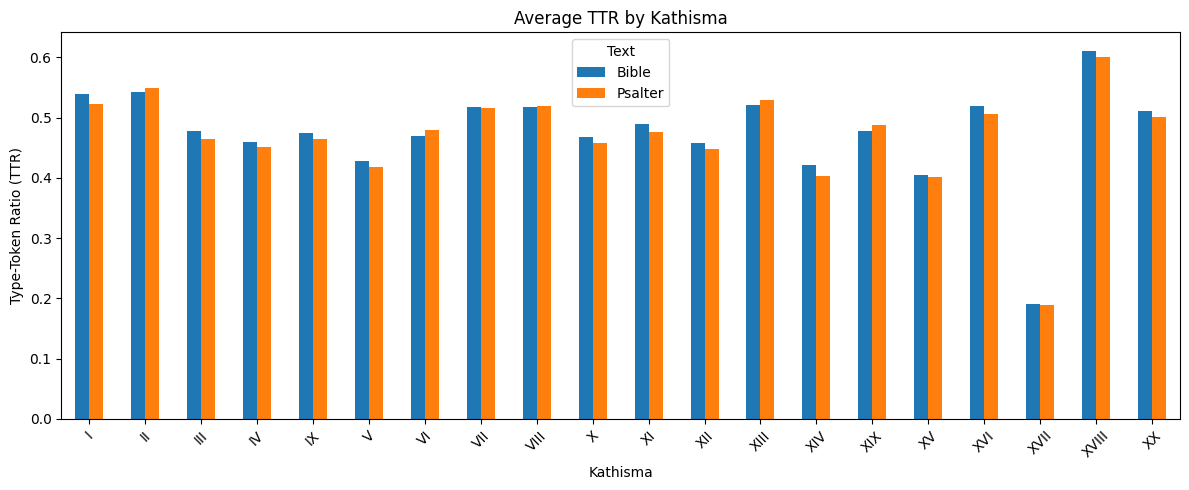

In [65]:
kathisma_metrics["TTR"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average TTR by Kathisma")
plt.xlabel("Kathisma")
plt.ylabel("Type-Token Ratio (TTR)")
plt.xticks(rotation=45)
plt.legend(title="Text")
plt.tight_layout()
plt.show()

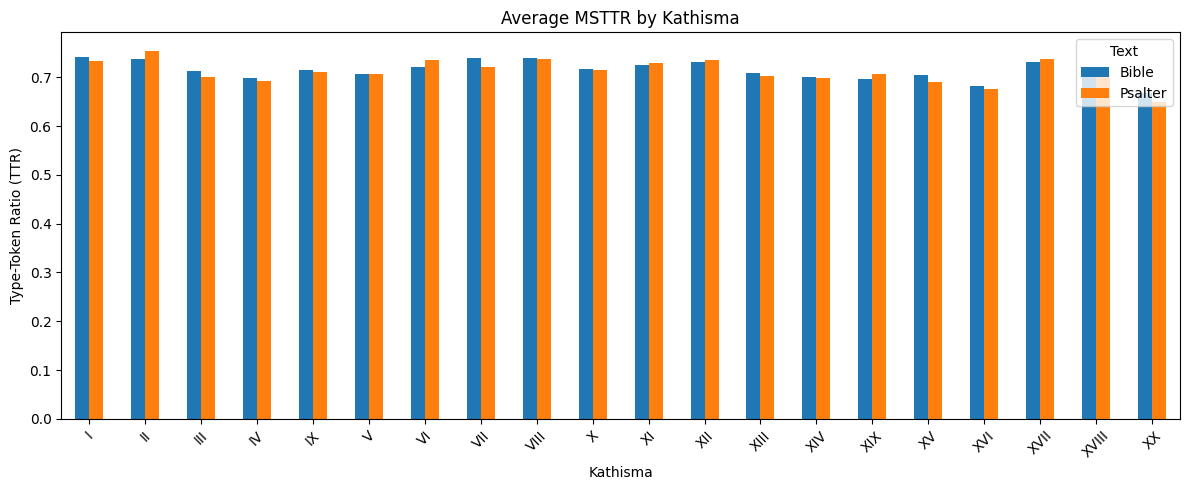

In [66]:
kathisma_metrics["MSTTR"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average MSTTR by Kathisma")
plt.xlabel("Kathisma")
plt.ylabel("Type-Token Ratio (TTR)")
plt.xticks(rotation=45)
plt.legend(title="Text")
plt.tight_layout()
plt.show()

**A possible pattern:**

* Early kathismas (especially II and VI) → Psalter has slightly higher diversity.
* Later kathismas (XV, XX) → Bible has noticeably higher diversity.

This could suggest that the Psalter is not simply "more literal" or "more poetic," but may have localized **stylistic decisions**.

# Cohesive Makers

In [67]:
cohesive_markers = {
    "additive": [
        "and", "also", "moreover", "furthermore",
        "in addition", "besides"
    ],
    
    "adversative": [
        "but", "however", "yet",
        "nevertheless", "instead"
    ],
    
    "causal": [
        "therefore", "thus", "so",
        "because", "for this reason"
    ],
    
    "temporal": [
        "then", "afterward", "finally",
        "before", "meanwhile"
    ]
}

In [68]:
import pandas as pd
import re
from collections import Counter

# Define cohesive markers
cohesive_markers = {
    "additive": [
        "and", "also", "moreover", "furthermore", "besides", 
        "in addition"
    ],
    "adversative": [
        "but", "however", "yet", "nevertheless", "instead"
    ],
    "causal": [
        "because", "therefore", "thus", "so", "for this reason"
    ],
    "temporal": [
        "then", "after", "afterward", "finally", "before", "meanwhile"
    ]
}

# Flatten marker list
marker_list = [
    marker 
    for category in cohesive_markers.values() 
    for marker in category
]


def count_cohesive_markers(text):
    """
    Count cohesive markers in a text
    """
    text = text.lower()
    
    counts = {}
    
    for marker in marker_list:
        # word boundary matching
        counts[marker] = len(
            re.findall(r'\b' + re.escape(marker) + r'\b', text)
        )
    
    return sum(counts.values())


# Count words
def word_count(text):
    return len(re.findall(r"\b\w+\b", text))


# Apply counts
new_psalms["Cohesive_Markers"] = new_psalms["verse"].apply(count_cohesive_markers)
new_psalms["Word_Count"] = new_psalms["verse"].apply(word_count)


# Aggregate to Psalm level
cohesion_results = (
    new_psalms.groupby(["text", "Psalm"])
    .agg(
        Total_Words=("Word_Count", "sum"),
        Total_Cohesive_Markers=("Cohesive_Markers", "sum")
    )
    .reset_index()
)


# Normalize per 1000 words
cohesion_results["Markers_per_1000_words"] = (
    cohesion_results["Total_Cohesive_Markers"] /
    cohesion_results["Total_Words"] *
    1000
)

cohesion_results.head()

,text,Psalm,Total_Words,Total_Cohesive_Markers,Markers_per_1000_words
0,Bible,1.0,133,10,75.187970
1,Bible,2.0,199,12,60.301508
2,Bible,3.0,150,6,40.000000
3,Bible,4.0,165,7,42.424242
4,Bible,5.0,248,10,40.322581


In [69]:
cohesion_compare = cohesion_results.pivot(
    index="Psalm",
    columns="text",
    values="Markers_per_1000_words"
)

cohesion_compare.head()

text,Bible,Psalter
Psalm,,
1.0,75.187970,78.014184
2.0,60.301508,60.747664
3.0,40.000000,36.231884
4.0,42.424242,53.571429
5.0,40.322581,39.840637


In [73]:
cohesion_compare["Difference"] = cohesion_compare["Bible"] - cohesion_compare["Psalter"]

cohesion_compare["Difference"].describe()

count    150.000000
mean      -0.529269
std        9.628573
min      -22.799423
25%       -7.673388
50%       -0.434931
75%        5.311339
max       27.097551
Name: Difference, dtype: float64

This is the important part.
Your typical Psalm differs by about ±9.6 markers per 1,000 words.
Because:

$9.63>>0.529$

the average difference is being canceled out by Psalms going in opposite directions.
In other words:


Some Psalms have much higher cohesion in the Psalter

Some Psalms have much higher cohesion in the Bible

There is not a consistent global trend.

In [74]:
cohesion_compare["Difference"].mean()

-0.5292690911653464

In [75]:
cohesion_compare.sort_values("Difference").head(10)

text,Bible,Psalter,Difference
Psalm,,,
66.0,31.746032,54.545455,-22.799423
51.0,72.538860,91.954023,-19.415163
99.0,60.975610,79.545455,-18.569845
126.0,8.547009,26.315789,-17.768781
53.0,46.153846,63.063063,-16.909217
6.0,42.168675,59.071730,-16.903055
19.0,48.484848,64.516129,-16.031281
121.0,22.058824,37.313433,-15.254609
110.0,48.192771,62.857143,-14.664372


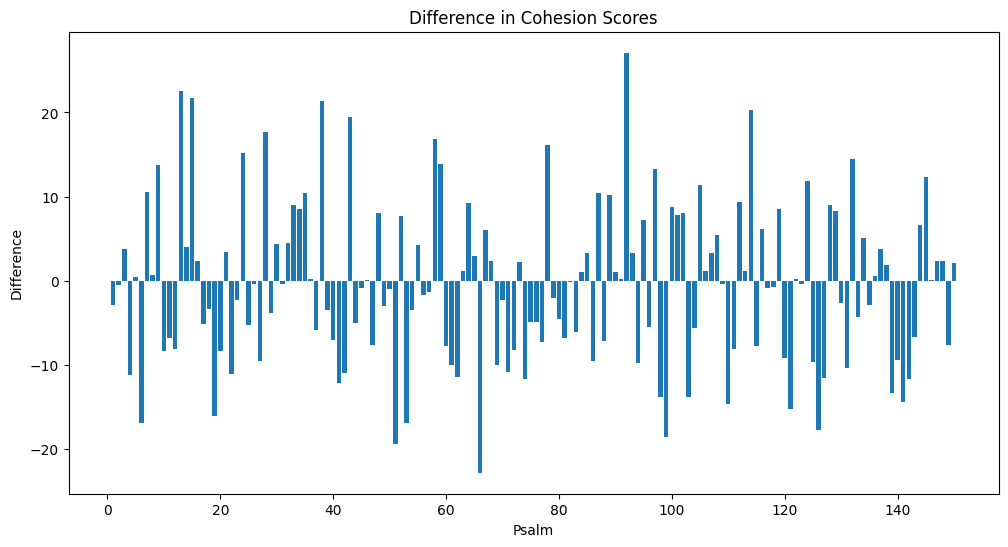

In [79]:
plt.figure(figsize=(12, 6))
plt.bar(cohesion_compare.index, cohesion_compare['Difference'])
plt.xlabel('Psalm')
plt.ylabel('Difference')
plt.title('Difference in Cohesion Scores')
plt.show()


* If the Psalter was translated with the goal of sounding more natural in English or closer to contemporary English usage, you might expect fewer explicit cohesive markers and therefore lower cohesion scores.
* If the Psalter was translated with a stronger emphasis on preserving Greek structure, liturgical phrasing, or source-text relationships, it might retain or even increase explicit cohesive markers, resulting in higher cohesion scores.
* Likewise, if the Bible translation prioritizes readability and natural English, it could show lower cohesion scores than the Psalter despite translating the same underlying content.


Positive Difference → Bible cohesion score is higher than Psalter.

Negative Difference → Psalter cohesion score is higher than Bible.

Difference = 0 → Same cohesion score

In [87]:
import numpy as np 
cohesion_compare['Observation'] = np.where(
    cohesion_compare['Difference'] > 0,
    'Bible',
    'Psalter'
)

In [92]:
cohesion_compare['Observation'].value_counts()

Observation
Psalter    80
Bible      70
Name: count, dtype: int64

In [96]:
cohes = pd.DataFrame(cohesion_compare['Observation'].value_counts()).T

cohes = cohes.rename(index={'count': 'Cohesive Makers'})

cohes

Observation,Psalter,Bible
Cohesive Makers,80,70


We can see that there is 10 mover Psalms from the Psalter that has a higher cohesion score, meaning there are more cohesion words, such as `therefore`, `thus`, and `however`. This can help conclude the higher purposeful emphasis to preserve more of the Greek structure, and litgurical Phrasing. This is what contrbutes to the higher cohesion scores.

In [98]:
translationese = df.T

translationese = pd.concat([translationese, cohes])

translationese

,Bible,Psalter
MSTTR,0.713610,0.710904
TTR,0.501613,0.495528
Cohesive Makers,70.000000,80.000000


# Unigram Bag-of-POS